# Application and Interpretation of a Decision Tree for Classification

This notebook demonstrates the training of a Decision Tree model for a classification problem and, more importantly, explores three methods for interpreting its decisions, leveraging its nature as a "white box" model.

**Dataset:** We will use the classic **Iris** dataset, which contains measurements of three species of flowers.

**Interpretation Objectives:**
1.  **Full Tree Visualization:** Plot the tree to understand the decision flow.
2.  **Feature Importance Analysis:** Quantify which features are most decisive for the model.
3.  **Extraction of Text-Based Decision Rules:** Convert the tree into a set of human-readable rules.

### Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, classification_report

# Visualization settings
sns.set_style("whitegrid")

### Loading and Preparing the Data

In [2]:
# Load the Iris dataset
iris_dataset = load_iris()
features = iris_dataset.data
target = iris_dataset.target
feature_names = iris_dataset.feature_names
class_names = iris_dataset.target_names

# Convert to a Pandas DataFrame for easier visualization
iris_df = pd.DataFrame(features, columns=feature_names)
iris_df["species"] = target
# Map numeric target to species names
iris_df["species_name"] = iris_df["species"].map(
    {0: "setosa", 1: "versicolor", 2: "virginica"}
)

iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


### Splitting into Training and Test Sets

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.3, random_state=42, stratify=target
)

### Training the Decision Tree Model

To ensure our tree is easily visualizable, we will limit its maximum depth (`max_depth=3`). This prevents it from growing too large and becoming unreadable.

In [4]:
# Instantiate the classifier
# We use max_depth=3 so the tree doesn't get too large and is easy to interpret
decision_tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)

# Train the model
decision_tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

### Evaluating the Model

Before interpreting, let's check if the model has a reasonable performance.

In [5]:
# Make predictions on the test set
predictions = decision_tree_model.predict(X_test)

# Calculate the accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy:.4f}\n")

# Display the full classification report
print("Classification Report:")
print(classification_report(y_test, predictions, target_names=class_names))

Model Accuracy: 0.9778

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.93      0.97        15
   virginica       0.94      1.00      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



## Interpretation Analysis

Now, let's apply the three interpretation techniques.

### Technique 1: Full Tree Visualization

Let's plot the structure of the tree. Each node shows:
- The splitting condition (e.g., `petal width (cm) <= 0.8`)
- The Gini impurity of the node
- The number of samples that reached the node (`samples`)
- The distribution of samples per class (`value`)
- The majority class in the node (`class`)

Text(0.5, 1.0, 'Decision Tree Visualization (max_depth=3)')

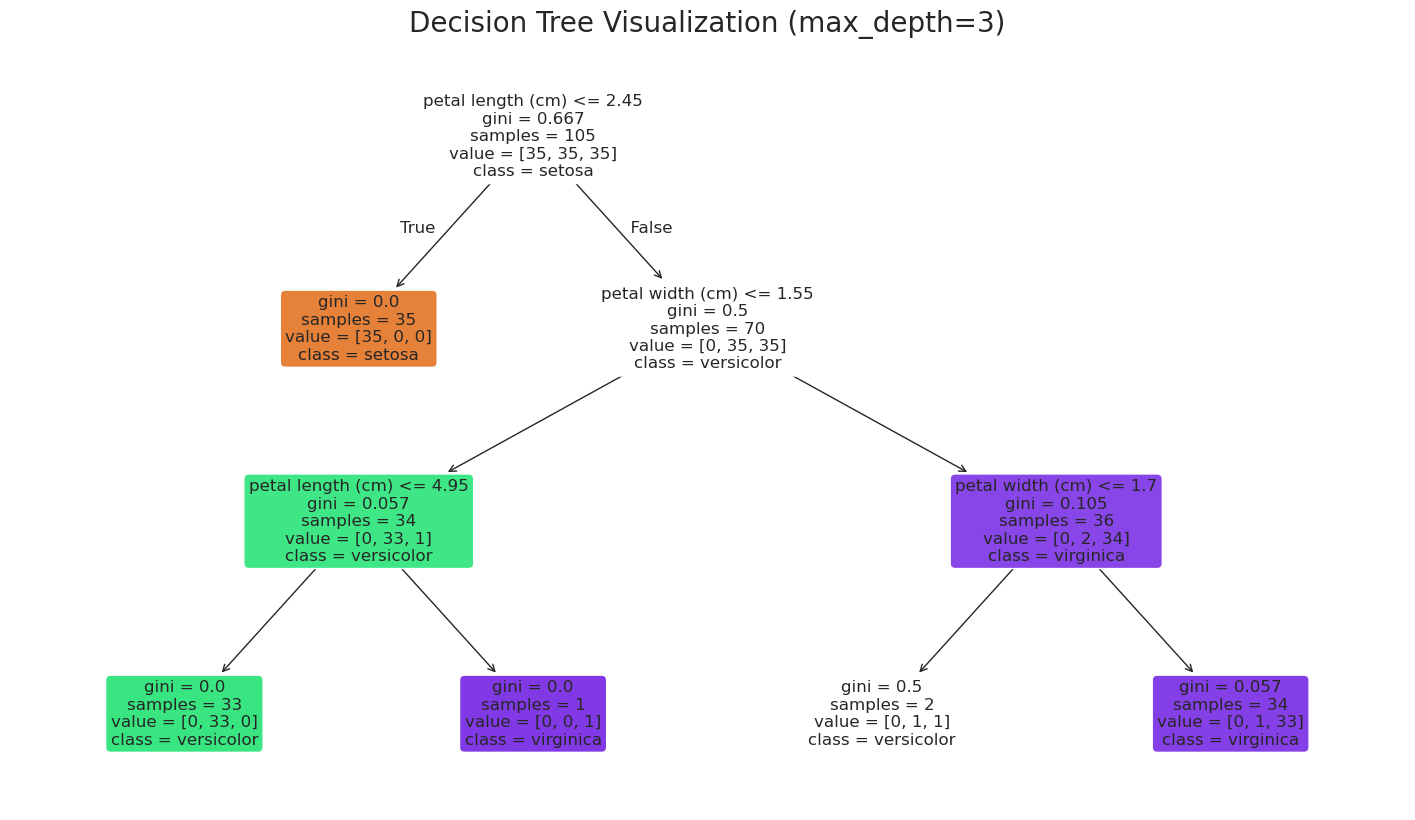

In [6]:
plt.figure(figsize=(18, 10))
plot_tree(
    decision_tree_model,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,  # Colors the nodes to indicate the majority class
    rounded=True,  # Rounded corners on nodes
    fontsize=12,
)
plt.title("Decision Tree Visualization (max_depth=3)", fontsize=20)

### Technique 2: Feature Importance Analysis

The tree calculates which features contributed most to reducing impurity. We can visualize this to understand which characteristics are most important for the classification.

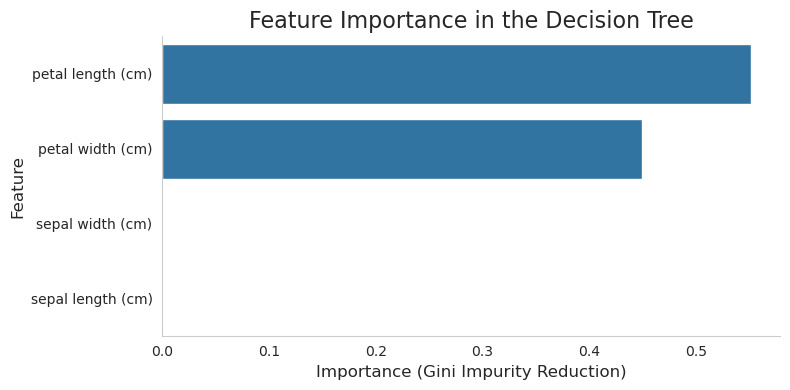

In [7]:
# Get feature importances
importances = decision_tree_model.feature_importances_

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": importances}
).sort_values(by="Importance", ascending=False)

# Plot the bar chart
plt.figure(figsize=(8, 4))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df)
plt.title("Feature Importance in the Decision Tree", fontsize=16)
plt.xlabel("Importance (Gini Impurity Reduction)", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.grid(False)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

From the analysis, we can see that `petal width (cm)` and `petal length (cm)` are by far the most important features for the model.

### Technique 3: Extracting Text-Based Decision Rules

For larger trees or when a visualization is not practical, we can export the rules in text format. Each line represents the path to a prediction.

In [8]:
text_rules = export_text(decision_tree_model, feature_names=list(feature_names))
print("Decision Tree Rules:\n")
print(text_rules)

Decision Tree Rules:

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.55
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.55
|   |   |--- petal width (cm) <= 1.70
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.70
|   |   |   |--- class: 2



**How to read the rules above?**

For example, the rule to classify a flower as `setosa` is very simple:
- `|--- petal width (cm) <= 0.80`
  - `|--- class: setosa`
  
This means: **IF** the petal width is less than or equal to 0.80 cm, **THEN** the model classifies the flower as `setosa`.

A more complex rule:
- `|--- petal width (cm) > 0.80`
  - `|--- petal width (cm) <= 1.75`
    - `|--- petal length (cm) <= 4.95`
      - `|--- class: versicolor`

This translates to: **IF** the petal width is greater than 0.80 cm **AND** the petal width is less than or equal to 1.75 cm **AND** the petal length is less than or equal to 4.95 cm, **THEN** the model classifies the flower as `versicolor`.